# The EWMA Control Chart — A Beginner's Guide

This notebook builds up the **Exponentially Weighted Moving Average (EWMA) control chart** from scratch, assuming no prior background in statistical process control (SPC). Every formula is written out in full, and every idea is immediately followed by a picture.

## 1.1 What is a control chart?

Imagine a factory machine that fills bottles with 500 ml of liquid. Even when everything is working perfectly, the *actual* amount in each bottle varies slightly around 500 ml — this is natural, unavoidable **random variation**. We call a process that only has this kind of variation **in control**.

Sometimes something goes wrong — a valve wears out, a sensor drifts — and the *average* fill volume starts to shift away from 500 ml. This is **special-cause variation**, and we want to detect it as quickly as possible.

A **control chart** is a plot of a process statistic over time, together with a **center line (CL)** and **control limits (UCL/LCL)**. As long as points stay inside the limits (and don't form suspicious patterns), we believe the process is in control. A point outside the limits is an **alarm**: it signals that the process may have changed.

## 1.2 Why EWMA, and not just "plot the raw data"?

The simplest control chart (a **Shewhart chart**) plots each new observation and flags it if it falls outside $\mu_0 \pm 3\sigma$. This works well for **large, sudden** shifts, but it has a blind spot: a **small, sustained** shift (say, half a standard deviation) might never push any *single* point outside $\pm 3\sigma$, even though the process has genuinely changed.

The **EWMA chart** fixes this by plotting a statistic that has *memory*: it is a weighted average of **all** past observations, with **recent observations weighted more heavily** and **older observations fading away exponentially**. This makes it much more sensitive to small, persistent shifts, while still behaving sensibly for large shifts.

> **Analogy:** think of the EWMA statistic as a rumour spreading through a small town. Today's news carries the most weight, yesterday's news is still remembered but slightly faded, news from last week is barely a whisper. A new consistent rumour (a real process shift) gradually takes over the town's opinion — while a single one-off event (random noise) fades away and is forgotten.

## 1.3 Roadmap

1. Define the EWMA statistic and unpack the recursion.
2. Derive its mean, variance, and the resulting control limits.
3. Simulate an in-control process and build our first EWMA chart.
4. Inject a process shift and watch the EWMA chart catch it.
5. Explore how the tuning parameters $\lambda$ and $L$ change chart behaviour.
6. Quantify chart performance with the **Average Run Length (ARL)**, estimated by Monte Carlo simulation.


## 2. Setup

We only need `numpy` for simulation and math, `pandas` to keep results tidy, and `matplotlib` for plotting. We fix a random seed so that this notebook produces the exact same numbers and pictures every time it is run — reproducibility is a core good practice in simulation studies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fixed seed -> reproducible simulations
RNG = np.random.default_rng(seed=795)

# A clean, readable default style for all plots in this notebook
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

# Colour palette used consistently throughout
COL_DATA   = "#4C72B0"   # raw data / EWMA line
COL_CL     = "#55A868"   # center line
COL_LIMITS = "#C44E52"   # control limits
COL_OOC    = "#C44E52"   # out-of-control points


## 3. The EWMA statistic

Let $X_1, X_2, X_3, \dots$ be the sequence of observations coming off the process (individual measurements, or subgroup means). The **EWMA statistic** $Z_i$ is defined recursively:

$$
Z_i = \lambda X_i + (1-\lambda) Z_{i-1}, \qquad i = 1, 2, 3, \dots
$$

with starting value $Z_0 = \mu_0$, the known (or estimated) in-control process mean, and smoothing parameter $\lambda \in (0, 1]$.

### 3.1 Unpacking the recursion

If we repeatedly substitute the recursion into itself, we get the equivalent **weighted-sum form**:

$$
Z_i = \lambda \sum_{j=0}^{i-1} (1-\lambda)^{j} X_{i-j} \; + \; (1-\lambda)^{i}\, \mu_0
$$

Look closely at the weights $\lambda(1-\lambda)^j$ attached to each past observation $X_{i-j}$:

* the **most recent** observation ($j=0$) gets weight $\lambda$,
* the observation from one step ago gets weight $\lambda(1-\lambda)$,
* two steps ago: $\lambda(1-\lambda)^2$, and so on —

the weights **decay exponentially** into the past. This is exactly where the name "Exponentially Weighted Moving Average" comes from.

### 3.2 The role of $\lambda$

* **Small $\lambda$** (e.g. 0.05): weights decay slowly &rarr; long memory, very smooth statistic, highly sensitive to small sustained shifts, but slower to react to large sudden shifts.
* **Large $\lambda$** (close to 1): weights decay quickly &rarr; short memory, jumpy statistic. When $\lambda = 1$, $Z_i = X_i$ and the **EWMA chart becomes an ordinary Shewhart chart**.

The plot below makes this concrete: it shows the weight $\lambda(1-\lambda)^j$ given to an observation $j$ steps in the past, for a few choices of $\lambda$.

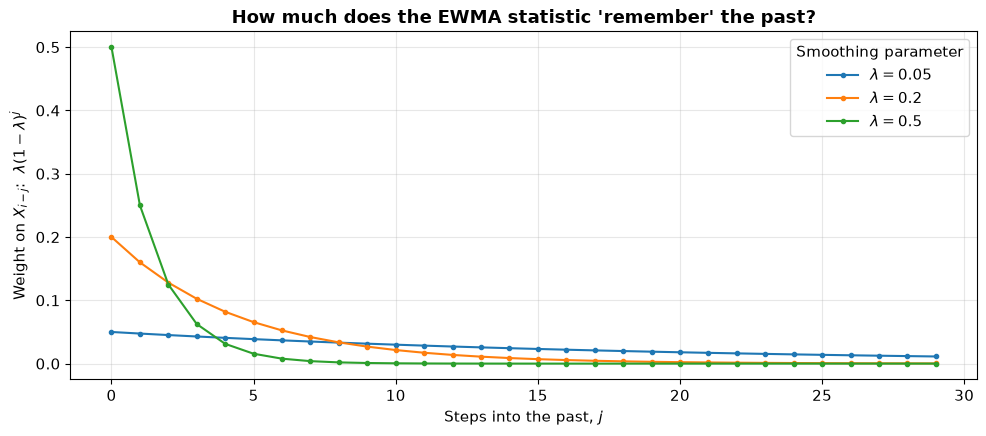

In [2]:
lags = np.arange(0, 30)
lambdas_demo = [0.05, 0.2, 0.5]

fig, ax = plt.subplots()
for lam in lambdas_demo:
    weights = lam * (1 - lam) ** lags
    ax.plot(lags, weights, marker="o", markersize=3, label=fr"$\lambda={lam}$")

ax.set_xlabel("Steps into the past, $j$")
ax.set_ylabel(r"Weight on $X_{i-j}$:  $\lambda(1-\lambda)^{j}$")
ax.set_title("How much does the EWMA statistic 'remember' the past?")
ax.legend(title=r"Smoothing parameter")
plt.tight_layout()
plt.show()


## 4. Mean, variance, and control limits

To build a control chart we need to know how $Z_i$ behaves *when the process is in control*, i.e. when every $X_i \sim N(\mu_0, \sigma^2)$ independently.

### 4.1 Mean

Because $Z_i$ is a weighted average of the $X_i$'s (and $\mu_0$), and $E[X_i]=\mu_0$ for all $i$, we get

$$
E[Z_i] = \mu_0 \qquad \text{for all } i.
$$

So the **center line** of the EWMA chart is simply $CL = \mu_0$.

### 4.2 Exact variance

Using $\text{Var}(X_i) = \sigma^2$ and independence of the $X_i$, the variance of the weighted-sum form is a finite geometric sum:

$$
\sigma_{Z_i}^2 = \sigma^2 \lambda^2 \sum_{j=0}^{i-1}(1-\lambda)^{2j}
= \sigma^2\left(\frac{\lambda}{2-\lambda}\right)\Big[1-(1-\lambda)^{2i}\Big]
$$

Notice the factor $\big[1-(1-\lambda)^{2i}\big]$: it starts small (near 0 when $i=1$) and grows toward 1 as $i \to \infty$. This means the EWMA statistic has **smaller variance in its earliest points**, and the variance **inflates toward a steady-state value** as more data arrive.

### 4.3 Asymptotic (steady-state) variance

Taking $i \to \infty$, the bracketed term $\to 1$ and we get the simpler, time-invariant **asymptotic variance**:

$$
\sigma_{Z}^2 = \sigma^2 \left(\frac{\lambda}{2-\lambda}\right)
$$

### 4.4 Control limits (Case K: known $\mu_0, \sigma$)

The standard $L$-sigma control limits are $CL \pm L \cdot \sigma_{Z_i}$. This gives two versions:

**Exact, time-varying limits** (tighter early on, correctly reflecting the lower early-point variance):

$$
UCL_i,\, LCL_i = \mu_0 \; \pm \; L\, \sigma \sqrt{\dfrac{\lambda}{2-\lambda}\Big[1-(1-\lambda)^{2i}\Big]}
$$

**Asymptotic, steady-state limits** (constant width, simpler, commonly used once $i$ is reasonably large):

$$
UCL,\, LCL = \mu_0 \; \pm \; L\, \sigma \sqrt{\dfrac{\lambda}{2-\lambda}}
$$

Here $L$ is the **width of the control limits**, in "number of EWMA standard deviations" — analogous to the "3" in a $3\sigma$ Shewhart chart, but tuned specifically for the EWMA statistic (typical values are $L \approx 2.7$–$3.0$).

### 4.5 Subgroup means instead of individual observations

If instead of single observations we plot subgroup means $\bar{X}_i$ of size $n$, everything above still holds with $\sigma$ replaced by $\sigma/\sqrt{n}$, since $\text{Var}(\bar X_i) = \sigma^2/n$. This is the setup used elsewhere in this course's Case K example ($n=5$, $\lambda=0.05$, $L=2.4859$, chosen so that $ARL_0 \approx 370$ — we will meet $ARL_0$ properly in Section 8).

## 5. Simulating an in-control process

Let's simulate $m = 50$ individual observations from an in-control process $X_i \sim N(\mu_0=0,\ \sigma_0=1)$. Plotting the raw data with $\pm 3\sigma$ reference limits gives us the familiar Shewhart-style picture, as a baseline before we build the EWMA chart.

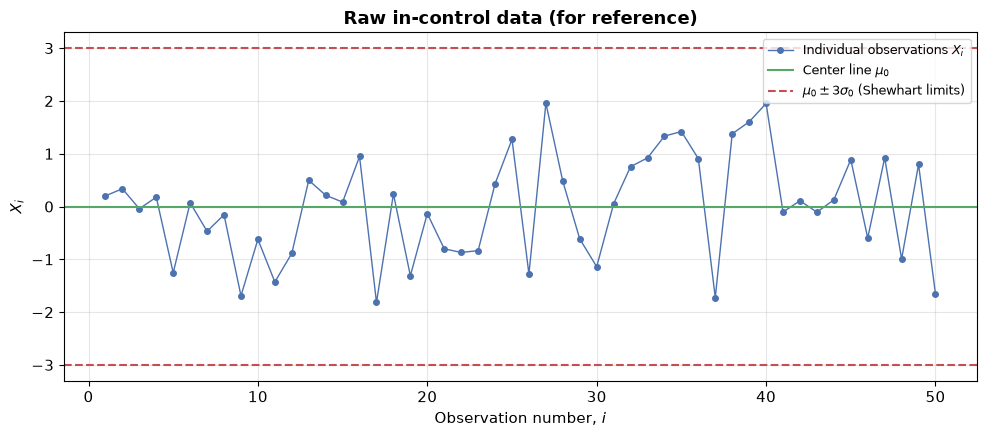

In [3]:
mu0, sigma0 = 0.0, 1.0
m = 50

x_ic = RNG.normal(loc=mu0, scale=sigma0, size=m)

fig, ax = plt.subplots()
idx = np.arange(1, m + 1)
ax.plot(idx, x_ic, marker="o", markersize=4, color=COL_DATA, linewidth=1, label="Individual observations $X_i$")
ax.axhline(mu0, color=COL_CL, linestyle="-", label="Center line $\\mu_0$")
ax.axhline(mu0 + 3 * sigma0, color=COL_LIMITS, linestyle="--", label=r"$\mu_0 \pm 3\sigma_0$ (Shewhart limits)")
ax.axhline(mu0 - 3 * sigma0, color=COL_LIMITS, linestyle="--")

ax.set_xlabel("Observation number, $i$")
ax.set_ylabel("$X_i$")
ax.set_title("Raw in-control data (for reference)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


## 6. Building the EWMA chart

Now we turn the same in-control data into an EWMA chart. We use $\lambda = 0.2$ and $L = 3$ — a classic beginner-friendly combination (Montgomery's textbook example). We compute the EWMA statistic recursively, then overlay **both** the exact (time-varying) and asymptotic control limits, so we can see them converge.

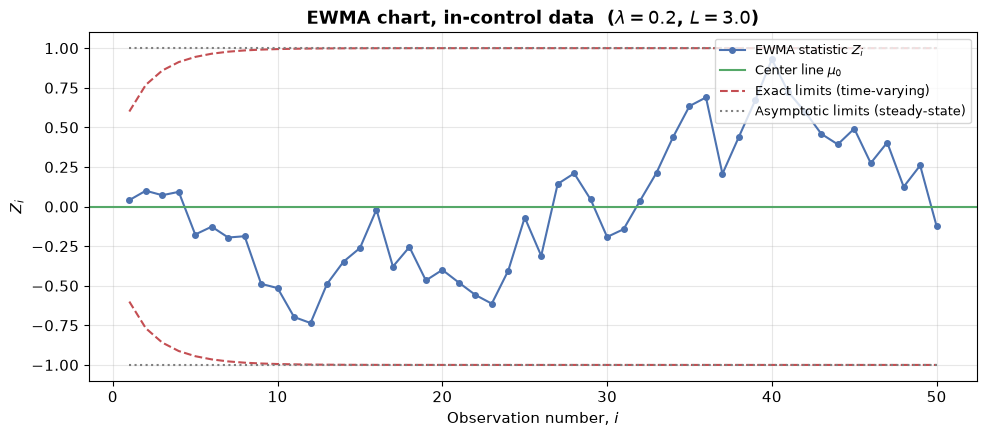

Notice how the exact limits start narrow and widen toward the constant
asymptotic limits as i grows -- exactly as the variance formula predicts.


In [4]:
def ewma_statistic(x, mu0, lam):
    '''Compute the EWMA statistic Z_i for a sequence x, given start value mu0.'''
    z = np.empty(len(x))
    z_prev = mu0
    for i, xi in enumerate(x):
        z_prev = lam * xi + (1 - lam) * z_prev
        z[i] = z_prev
    return z


def ewma_limits(mu0, sigma, lam, L, m, exact=True):
    '''Return (UCL, LCL) arrays of length m. If exact=False, returns the constant
    asymptotic limits broadcast to length m.'''
    i = np.arange(1, m + 1)
    factor = (lam / (2 - lam))
    if exact:
        var_i = sigma ** 2 * factor * (1 - (1 - lam) ** (2 * i))
    else:
        var_i = np.full(m, sigma ** 2 * factor)
    width = L * np.sqrt(var_i)
    return mu0 + width, mu0 - width


lam, L = 0.2, 3.0

z_ic = ewma_statistic(x_ic, mu0, lam)
ucl_exact, lcl_exact = ewma_limits(mu0, sigma0, lam, L, m, exact=True)
ucl_asym,  lcl_asym  = ewma_limits(mu0, sigma0, lam, L, m, exact=False)

fig, ax = plt.subplots()
ax.plot(idx, z_ic, marker="o", markersize=4, color=COL_DATA, label="EWMA statistic $Z_i$")
ax.axhline(mu0, color=COL_CL, label="Center line $\\mu_0$")
ax.plot(idx, ucl_exact, color=COL_LIMITS, linestyle="--", label="Exact limits (time-varying)")
ax.plot(idx, lcl_exact, color=COL_LIMITS, linestyle="--")
ax.plot(idx, ucl_asym, color="gray", linestyle=":", label="Asymptotic limits (steady-state)")
ax.plot(idx, lcl_asym, color="gray", linestyle=":")

ax.set_xlabel("Observation number, $i$")
ax.set_ylabel("$Z_i$")
ax.set_title(fr"EWMA chart, in-control data  ($\lambda={lam}$, $L={L}$)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print("Notice how the exact limits start narrow and widen toward the constant")
print("asymptotic limits as i grows -- exactly as the variance formula predicts.")


## 7. Detecting a process shift

Now let's make the process misbehave. We simulate $m=50$ observations again, but from observation 26 onward we shift the true mean from $\mu_0=0$ to $\mu_0 + \delta\sigma_0$ with $\delta = 0.75$ — a **small, sustained** shift, exactly the kind a Shewhart chart tends to miss.

We'll place the raw data and the EWMA chart side by side to see the difference in sensitivity.

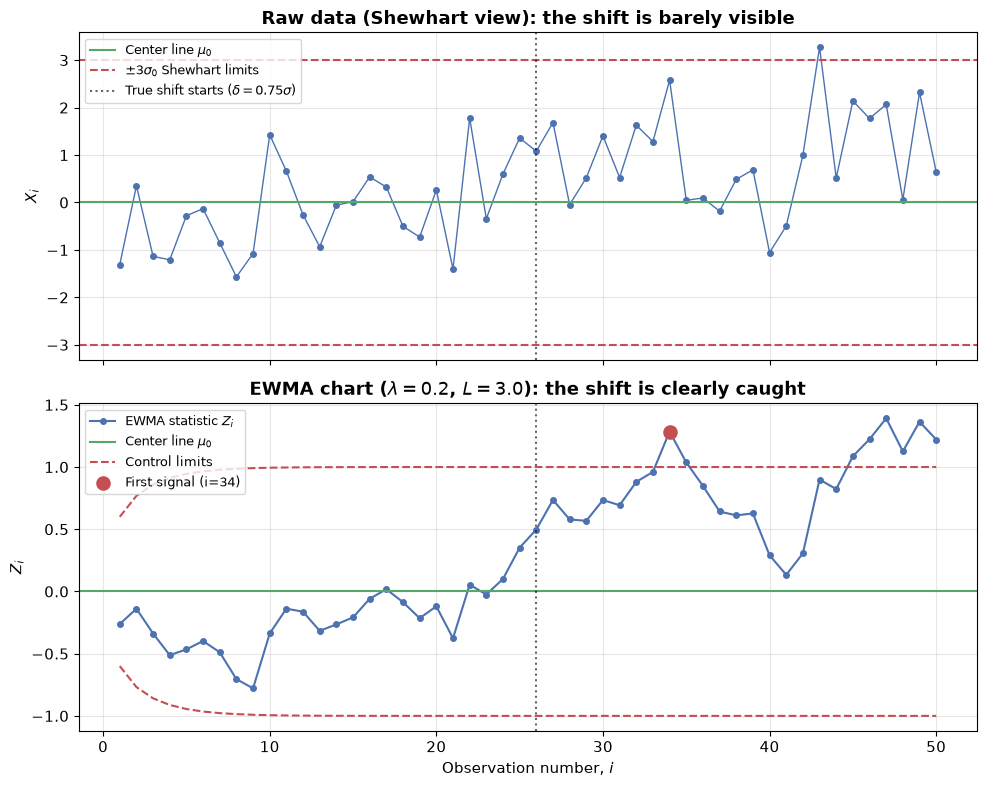

EWMA signalled at observation i=34, 8 points after the true shift began.


In [5]:
delta = 0.75
shift_point = 25  # 0-indexed: observations 0..24 in control, 25..49 shifted

x_shift = RNG.normal(loc=mu0, scale=sigma0, size=m)
x_shift[shift_point:] += delta * sigma0

z_shift = ewma_statistic(x_shift, mu0, lam)
ucl_a, lcl_a = ewma_limits(mu0, sigma0, lam, L, m, exact=True)

# First point where the EWMA signals (falls outside the exact control limits)
ooc_mask = (z_shift > ucl_a) | (z_shift < lcl_a)
first_signal = np.argmax(ooc_mask) + 1 if ooc_mask.any() else None

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(idx, x_shift, marker="o", markersize=4, color=COL_DATA, linewidth=1)
ax.axhline(mu0, color=COL_CL, label="Center line $\\mu_0$")
ax.axhline(mu0 + 3 * sigma0, color=COL_LIMITS, linestyle="--", label=r"$\pm 3\sigma_0$ Shewhart limits")
ax.axhline(mu0 - 3 * sigma0, color=COL_LIMITS, linestyle="--")
ax.axvline(shift_point + 1, color="black", linestyle=":", alpha=0.6, label=fr"True shift starts ($\delta={delta}\sigma$)")
ax.set_ylabel("$X_i$")
ax.set_title("Raw data (Shewhart view): the shift is barely visible")
ax.legend(loc="upper left", fontsize=9)

ax = axes[1]
ax.plot(idx, z_shift, marker="o", markersize=4, color=COL_DATA, label="EWMA statistic $Z_i$")
ax.axhline(mu0, color=COL_CL, label="Center line $\\mu_0$")
ax.plot(idx, ucl_a, color=COL_LIMITS, linestyle="--", label="Control limits")
ax.plot(idx, lcl_a, color=COL_LIMITS, linestyle="--")
ax.axvline(shift_point + 1, color="black", linestyle=":", alpha=0.6)
if first_signal:
    ax.scatter([first_signal], [z_shift[first_signal - 1]], color=COL_OOC, s=90, zorder=5,
               label=f"First signal (i={first_signal})")
ax.set_xlabel("Observation number, $i$")
ax.set_ylabel("$Z_i$")
ax.set_title(fr"EWMA chart ($\lambda={lam}$, $L={L}$): the shift is clearly caught")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

if first_signal:
    print(f"EWMA signalled at observation i={first_signal}, "
          f"{first_signal - (shift_point + 1)} points after the true shift began.")
else:
    print("EWMA did not signal within the simulated window.")


## 8. The effect of $\lambda$ and $L$ on chart behaviour

We saw in Section 3 that $\lambda$ controls how much memory the EWMA statistic has. Let's see this directly on the shifted dataset from Section 7: we recompute the EWMA chart for a few values of $\lambda$ (keeping $L=3$ fixed) and compare.

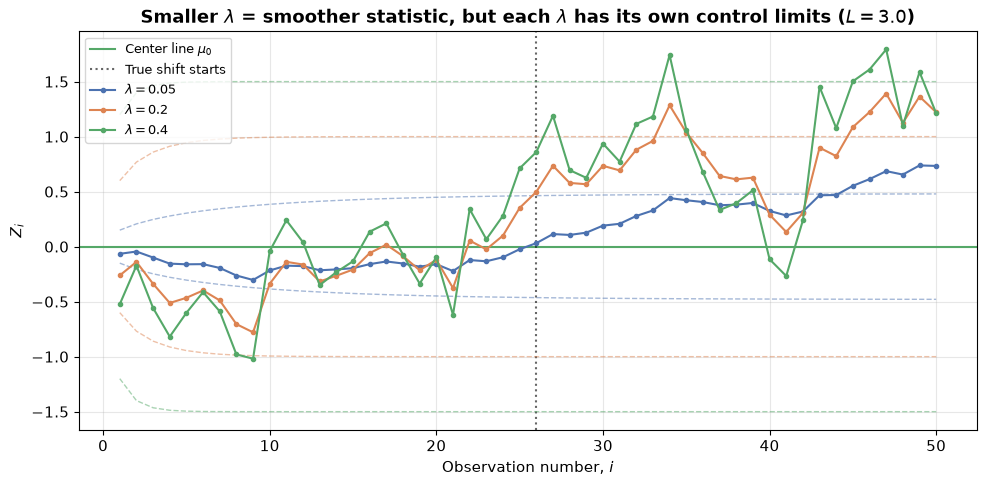

Small lambda (0.05): very smooth, reacts slowly at first but eventually tracks the new mean closely.
Large lambda (0.4): jumpier, closer to the raw data, reacts faster to sudden changes.


In [6]:
lambdas_compare = [0.05, 0.2, 0.4]

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(mu0, color=COL_CL, label="Center line $\\mu_0$")
ax.axvline(shift_point + 1, color="black", linestyle=":", alpha=0.6, label="True shift starts")

for lam_i, color in zip(lambdas_compare, ["#4C72B0", "#DD8452", "#55A868"]):
    z_i = ewma_statistic(x_shift, mu0, lam_i)
    ucl_i, lcl_i = ewma_limits(mu0, sigma0, lam_i, L, m, exact=True)
    ax.plot(idx, z_i, color=color, marker="o", markersize=3, label=fr"$\lambda={lam_i}$")
    ax.plot(idx, ucl_i, color=color, linestyle="--", alpha=0.5, linewidth=1)
    ax.plot(idx, lcl_i, color=color, linestyle="--", alpha=0.5, linewidth=1)

ax.set_xlabel("Observation number, $i$")
ax.set_ylabel("$Z_i$")
ax.set_title(fr"Smaller $\lambda$ = smoother statistic, but each $\lambda$ has its own control limits ($L={L}$)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print("Small lambda (0.05): very smooth, reacts slowly at first but eventually tracks the new mean closely.")
print("Large lambda (0.4): jumpier, closer to the raw data, reacts faster to sudden changes.")


A well-known combination from this course's own EWMA case study is $\lambda = 0.05$, $L = 2.4859$ (subgroup size $n=5$) — chosen specifically so that the chart's in-control Average Run Length is about 370, matching a standard $3\sigma$ Shewhart chart. The next section explains exactly what that means, and how such an $L$ is actually found.

## 9. Average Run Length (ARL)

So far we've judged the chart "by eye". To compare charts rigorously — and to choose $\lambda$ and $L$ properly — we need a numerical performance measure.

### 9.1 Definition

The **Run Length** $N$ is the number of points plotted **until the first out-of-control signal**:

$$
N = \min\{\, i : Z_i > UCL_i \ \text{or} \ Z_i < LCL_i \,\}
$$

$N$ is random (it depends on the random data), so we summarise its distribution by its mean, the **Average Run Length**:

$$
ARL = E[N]
$$

Two regimes matter:

* $\boldsymbol{ARL_0}$ — the in-control ARL (process actually at $\mu_0$). We want this to be **large**: a big ARL$_0$ means few false alarms. A classic benchmark is $ARL_0 \approx 370$, matching a $3\sigma$ Shewhart chart's false-alarm rate.
* $\boldsymbol{ARL_1}$ — the out-of-control ARL (process shifted by $\delta\sigma$). We want this to be **small**: the chart should signal quickly once something is genuinely wrong.

### 9.2 Estimating ARL by Monte Carlo simulation

There is no simple closed-form formula for the EWMA chart's ARL, so — just like the SAS Monte Carlo study elsewhere in this course — we **estimate it by simulation**:

1. Fix $\lambda$, $L$, and a shift size $\delta$ (in units of $\sigma$).
2. Simulate a long sequence of observations $X_i \sim N(\mu_0 + \delta\sigma,\ \sigma^2)$.
3. Compute the EWMA statistic and find the first $i$ where it signals; record this run length $N$.
4. Repeat steps 2–3 many times (e.g. 5,000 runs) and average the recorded run lengths.

We use the **asymptotic control limits** here (constant width), which is the standard convention for ARL studies since the chart quickly reaches steady state relative to typical run lengths.

In [7]:
def simulate_run_length(mu0, sigma0, lam, L, delta, max_len=2000, rng=None):
    '''Simulate one run length: number of points until the EWMA chart signals,
    for a process running at mean mu0 + delta*sigma0.'''
    if rng is None:
        rng = np.random.default_rng()

    true_mean = mu0 + delta * sigma0
    factor = lam / (2 - lam)
    asym_width = L * sigma0 * np.sqrt(factor)
    ucl, lcl = mu0 + asym_width, mu0 - asym_width

    z_prev = mu0
    for i in range(1, max_len + 1):
        xi = rng.normal(true_mean, sigma0)
        z_prev = lam * xi + (1 - lam) * z_prev
        if z_prev > ucl or z_prev < lcl:
            return i
    return max_len  # censored: did not signal within max_len points


def estimate_arl(mu0, sigma0, lam, L, delta, n_sims=5000, max_len=2000, rng=None):
    '''Monte Carlo estimate of the ARL for a given shift size delta.'''
    if rng is None:
        rng = np.random.default_rng()
    run_lengths = np.array([
        simulate_run_length(mu0, sigma0, lam, L, delta, max_len=max_len, rng=rng)
        for _ in range(n_sims)
    ])
    return run_lengths.mean(), run_lengths.std(ddof=1) / np.sqrt(n_sims)  # (ARL estimate, standard error)


In [8]:
# Course's Case K parameters: lambda=0.05, L=2.4859 (tuned so ARL0 ~= 370)
lam_course, L_course = 0.05, 2.4859
n_sims = 5000

arl0_est, arl0_se = estimate_arl(mu0, sigma0, lam_course, L_course, delta=0.0, n_sims=n_sims, rng=RNG)
print(f"Estimated ARL0 (lambda={lam_course}, L={L_course}): {arl0_est:.1f}  (SE = {arl0_se:.1f})")
print("Target from the course's Case K design: ARL0 ~= 370")


Estimated ARL0 (lambda=0.05, L=2.4859): 370.4  (SE = 4.9)
Target from the course's Case K design: ARL0 ~= 370


### 9.3 The ARL curve: how fast does the chart react to different shift sizes?

Now we repeat the Monte Carlo estimation across a grid of shift sizes $\delta = 0, 0.25, 0.5, \dots, 3.0$ (in units of $\sigma$), using the course's Case K parameters ($\lambda=0.05$, $L=2.4859$). This reproduces, in Python, the shape of the SAS Monte Carlo ARL study used elsewhere in this course.

In [9]:
deltas = np.arange(0.0, 3.01, 0.25)
arl_values = np.empty(len(deltas))
arl_se = np.empty(len(deltas))

for k, d in enumerate(deltas):
    arl_values[k], arl_se[k] = estimate_arl(mu0, sigma0, lam_course, L_course, delta=d,
                                             n_sims=n_sims, rng=RNG)

arl_table = pd.DataFrame({"shift (delta, in sigma units)": deltas,
                           "ARL estimate": arl_values.round(1),
                           "Std. error": arl_se.round(2)})
arl_table


,"shift (delta, in sigma units)",ARL estimate,Std. error
0,0.00,359.3,4.86
1,0.25,73.2,0.81
2,0.50,26.4,0.21
3,0.75,15.2,0.10
4,1.00,10.6,0.06
5,1.25,8.2,0.04
6,1.50,6.8,0.03
7,1.75,5.7,0.02
8,2.00,4.9,0.02
9,2.25,4.4,0.01


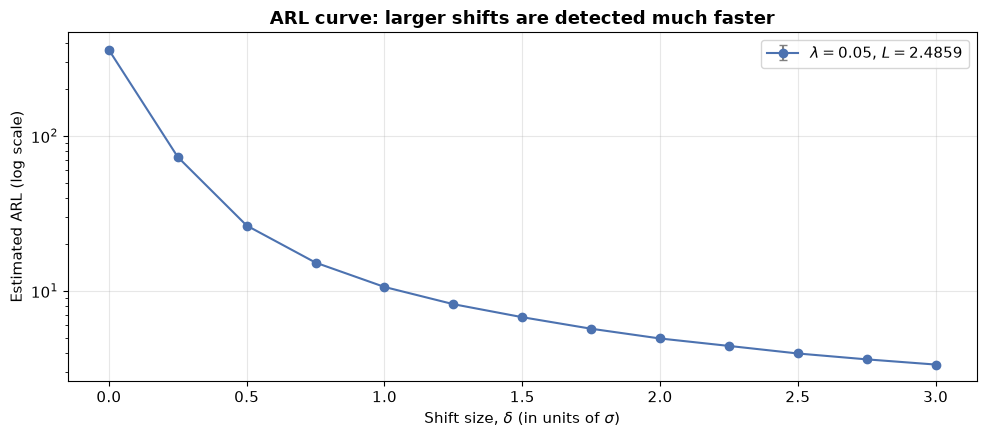

As delta grows from 0, the ARL drops sharply from ~370 (rare false alarms)
down toward small values (fast, reliable detection of large shifts).


In [10]:
fig, ax = plt.subplots()
ax.errorbar(deltas, arl_values, yerr=1.96 * arl_se, marker="o", color=COL_DATA,
            ecolor="gray", capsize=3, label=fr"$\lambda={lam_course}$, $L={L_course}$")
ax.set_yscale("log")
ax.set_xlabel(r"Shift size, $\delta$ (in units of $\sigma$)")
ax.set_ylabel("Estimated ARL (log scale)")
ax.set_title("ARL curve: larger shifts are detected much faster")
ax.legend()
plt.tight_layout()
plt.show()

print("As delta grows from 0, the ARL drops sharply from ~370 (rare false alarms)")
print("down toward small values (fast, reliable detection of large shifts).")


### 9.4 Effect of $\lambda$ on the ARL curve

Finally, let's directly compare two smoothing parameters, $\lambda=0.05$ and $\lambda=0.2$, **at the same $ARL_0 \approx 370$** benchmark (we simply reuse $L=3$ from Section 6, which happens to already sit close to a 370 in-control ARL for individual observations, alongside the course's tuned $\lambda=0.05, L=2.4859$ pair). This isolates the classic trade-off: small $\lambda$ is better for small shifts, but can be slower for large ones.

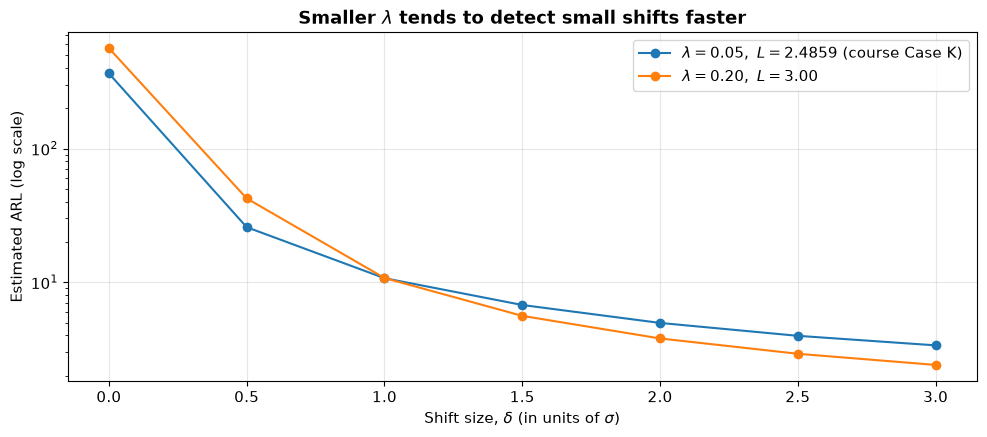

In [11]:
deltas_cmp = np.arange(0.0, 3.01, 0.5)

configs = [
    (r"$\lambda=0.05,\ L=2.4859$ (course Case K)", 0.05, 2.4859),
    (r"$\lambda=0.20,\ L=3.00$",                    0.20, 3.00),
]

fig, ax = plt.subplots()
for label, lam_c, L_c in configs:
    arl_c = np.array([estimate_arl(mu0, sigma0, lam_c, L_c, delta=d, n_sims=2000, rng=RNG)[0]
                       for d in deltas_cmp])
    ax.plot(deltas_cmp, arl_c, marker="o", label=label)

ax.set_yscale("log")
ax.set_xlabel(r"Shift size, $\delta$ (in units of $\sigma$)")
ax.set_ylabel("Estimated ARL (log scale)")
ax.set_title(r"Smaller $\lambda$ tends to detect small shifts faster")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Summary and key takeaways

| Concept | Formula |
|---|---|
| EWMA statistic | $Z_i = \lambda X_i + (1-\lambda)Z_{i-1}$, $Z_0=\mu_0$ |
| Mean | $E[Z_i] = \mu_0$ |
| Exact variance | $\sigma_{Z_i}^2 = \sigma^2\left(\frac{\lambda}{2-\lambda}\right)\left[1-(1-\lambda)^{2i}\right]$ |
| Asymptotic variance | $\sigma_Z^2 = \sigma^2\left(\frac{\lambda}{2-\lambda}\right)$ |
| Control limits | $\mu_0 \pm L\,\sigma_{Z_i}$ (exact) or $\mu_0 \pm L\,\sigma_Z$ (asymptotic) |
| Run length | $N=\min\{i: Z_i \text{ outside limits}\}$ |
| ARL | $E[N]$; want $ARL_0$ large, $ARL_1$ small |

**What we learned:**

* The EWMA statistic is a weighted average with **exponentially decaying memory**, controlled by $\lambda$.
* Its variance starts small and grows to a steady-state value — giving us **exact** (time-varying) and **asymptotic** (constant) control limits.
* Because it accumulates evidence over time, EWMA is **much more sensitive to small, sustained shifts** than a plain Shewhart chart, while a raw-data Shewhart view can miss them entirely.
* $\lambda$ and $L$ are **tuning knobs**: small $\lambda$ gives long memory (good for small shifts), larger $\lambda$ behaves more like a Shewhart chart (good for large, sudden shifts). $L$ trades off false alarms against detection speed.
* **ARL** is the standard yardstick for comparing charts: we want a large in-control ARL$_0$ (few false alarms) and a small out-of-control ARL$_1$ (fast detection), and — because no closed form exists — we estimate it via **Monte Carlo simulation**.

**Looking ahead:** this notebook used **Case K** throughout, i.e. $\mu_0$ and $\sigma$ were assumed *known*. In real applications, these are usually **estimated from a Phase I reference sample** before the chart is put to work monitoring new (Phase II) data — a natural next step once the mechanics here feel familiar.
